# Digital Twin Model Training & Comparison

This notebook demonstrates how to load the CWRU dataset, extract features, balance the data, and train multiple models (Random Forest, SVM, Gradient Boosting) to compare their performance.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Auto-reload modules to pick up changes in src
%load_ext autoreload
%autoreload 2

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data.loaders import CWRULoader
from src.features.signal_processing import extract_time_features, compute_fft
import src.models.classifiers
importlib.reload(src.models.classifiers)
from src.models.classifiers import FaultDiagnosisModel

print(f"Python Version: {sys.version}")

Python Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


## 1. Load Data
We will load a Normal file (97.mat) and a Faulty file (105.mat - Inner Race Fault).

In [2]:
DATA_DIR = r'../CWRU_Data'
loader = CWRULoader(DATA_DIR)

try:
    # Load Normal Data
    normal_signal = loader.load_file('97.mat')
    # Load Faulty Data (Inner Race)
    fault_signal = loader.load_file('105.mat')
    
    print(f"Normal Signal Length: {len(normal_signal)}")
    print(f"Fault Signal Length: {len(fault_signal)}")
except Exception as e:
    print(f"Error loading files: {e}")
    print("Please ensure '97.mat' and '105.mat' are in the CWRU_Data folder.")

Normal Signal Length: 243938
Fault Signal Length: 121265


## 2. Visualization
Let's compare the signals in Time and Frequency domains (FFT).

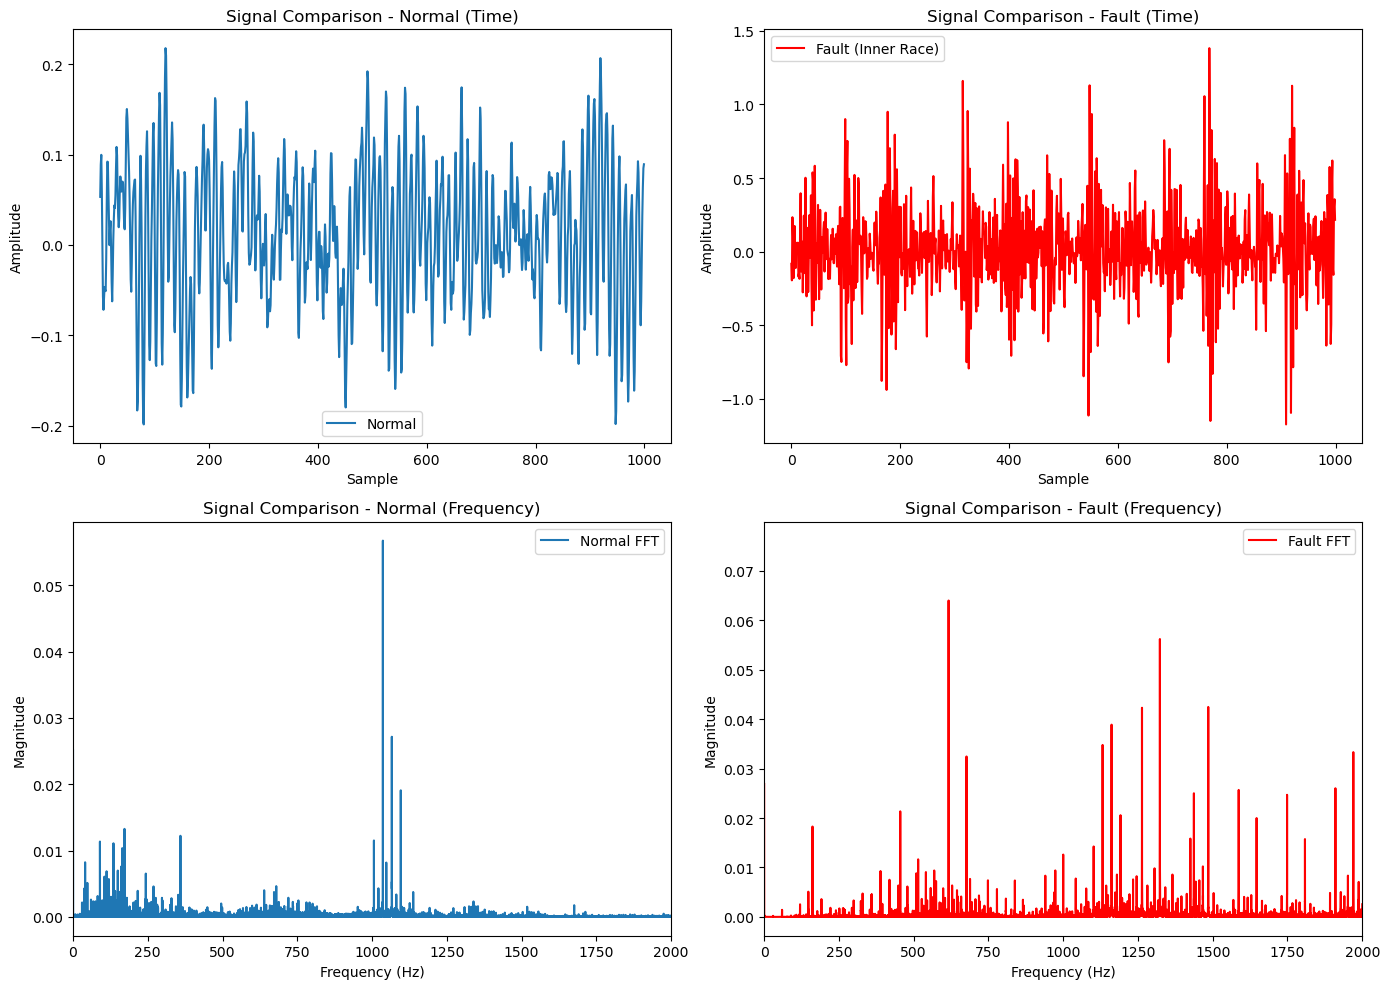

In [3]:
def plot_comparison(normal, fault, title, fs=12000):
    plt.figure(figsize=(14, 10))
    
    # Time Domain - Normal
    plt.subplot(2, 2, 1)
    plt.plot(normal[:1000], label='Normal')
    plt.legend()
    plt.title(f'{title} - Normal (Time)')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')

    # Time Domain - Fault
    plt.subplot(2, 2, 2)
    plt.plot(fault[:1000], color='red', label='Fault (Inner Race)')
    plt.legend()
    plt.title(f'{title} - Fault (Time)')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')

    # Frequency Domain (FFT) - Normal
    freq_n, mag_n = compute_fft(normal, fs)
    plt.subplot(2, 2, 3)
    plt.plot(freq_n, mag_n, label='Normal FFT')
    plt.legend()
    plt.title(f'{title} - Normal (Frequency)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 2000) # Zoom in on lower frequencies

    # Frequency Domain (FFT) - Fault
    freq_f, mag_f = compute_fft(fault, fs)
    plt.subplot(2, 2, 4)
    plt.plot(freq_f, mag_f, color='red', label='Fault FFT')
    plt.legend()
    plt.title(f'{title} - Fault (Frequency)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, 2000)

    plt.tight_layout()
    plt.show()

if 'normal_signal' in locals() and 'fault_signal' in locals():
    plot_comparison(normal_signal, fault_signal, 'Signal Comparison')

## 3. Feature Extraction & Dataset Creation
We will process all files to create a dataset for training.

In [4]:
def create_dataset(filenames, label, chunk_size=1000):
    features_list = []
    labels_list = []
    
    for filename in filenames:
        try:
            signal = loader.load_file(filename)
            # Split signal into chunks
            num_chunks = len(signal) // chunk_size
            for i in range(num_chunks):
                chunk = signal[i*chunk_size : (i+1)*chunk_size]
                # Extract features
                feats = extract_time_features(chunk)
                features_list.append(list(feats.values()))
                labels_list.append(label)
        except Exception as e:
            print(f"Skipping {filename}: {e}")
            
    return np.array(features_list), np.array(labels_list)

# Define file lists (example subset)
normal_files = ['97.mat', '98.mat']
inner_race_files = ['105.mat', '106.mat']
ball_fault_files = ['118.mat', '119.mat']
outer_race_files = ['130.mat', '131.mat']

print("Loading Normal Data...")
X_normal, y_normal = create_dataset(normal_files, 0)
print(f"Loaded {len(X_normal)} samples.")

print("Loading Inner Race Data...")
X_inner, y_inner = create_dataset(inner_race_files, 1)
print(f"Loaded {len(X_inner)} samples.")

print("Loading Ball Fault Data...")
X_ball, y_ball = create_dataset(ball_fault_files, 2)
print(f"Loaded {len(X_ball)} samples.")

print("Loading Outer Race Data...")
X_outer, y_outer = create_dataset(outer_race_files, 3)
print(f"Loaded {len(X_outer)} samples.")

X = np.concatenate([X_normal, X_inner, X_ball, X_outer])
y = np.concatenate([y_normal, y_inner, y_ball, y_outer])

print(f"Total Dataset Shape: {X.shape}")

Loading Normal Data...
Loaded 726 samples.
Loading Inner Race Data...
Loaded 242 samples.
Loading Ball Fault Data...
Loaded 243 samples.
Loading Outer Race Data...
Loaded 243 samples.
Total Dataset Shape: (1454, 7)


## 4. Data Analysis & Visualization
Before training, it is crucial to understand the distribution of our data. Imbalanced datasets can lead to biased models.

### 4.1 Class Distribution (Before Balancing)
We will visualize the number of samples for each class (Normal, Inner Race, Ball, Outer Race) to check for class imbalance.

C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_7272\343102305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


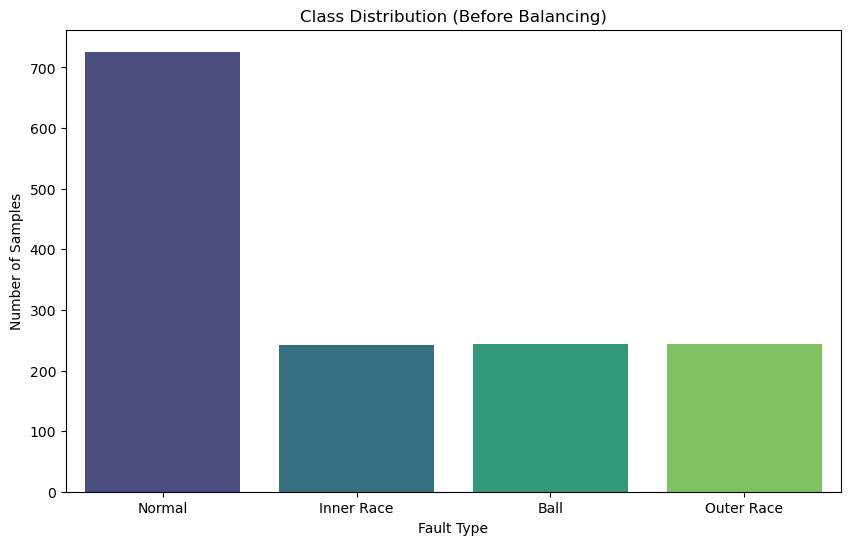

Class Counts: {'Normal': np.int64(726), 'Inner Race': np.int64(242), 'Ball': np.int64(243), 'Outer Race': np.int64(243)}


In [5]:
class_names = ['Normal', 'Inner Race', 'Ball', 'Outer Race']
unique, counts = np.unique(y, return_counts=True)
class_counts = dict(zip(class_names, counts))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Class Distribution (Before Balancing)')
plt.xlabel('Fault Type')
plt.ylabel('Number of Samples')
plt.show()

print("Class Counts:", class_counts)

### 4.2 Balancing the Data (SMOTE)
We will use **SMOTE (Synthetic Minority Over-sampling Technique)** to balance the dataset. This creates synthetic samples for the minority classes so that all classes have the same number of samples as the majority class.

Applying SMOTE to balance the dataset...
Original Dataset Shape: (1454, 7)
Balanced Dataset Shape: (2904, 7)


C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_7272\1149694346.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts_bal.keys()), y=list(class_counts_bal.values()), palette='viridis')


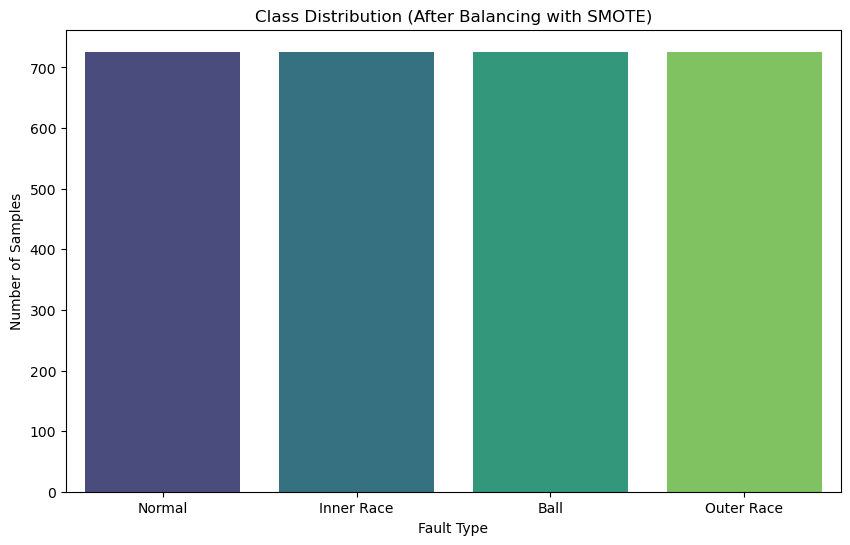

Balanced Class Counts: {'Normal': np.int64(726), 'Inner Race': np.int64(726), 'Ball': np.int64(726), 'Outer Race': np.int64(726)}


In [6]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to balance the dataset...")
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Original Dataset Shape: {X.shape}")
print(f"Balanced Dataset Shape: {X_balanced.shape}")

# Check new distribution
unique_bal, counts_bal = np.unique(y_balanced, return_counts=True)
class_counts_bal = dict(zip(class_names, counts_bal))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts_bal.keys()), y=list(class_counts_bal.values()), palette='viridis')
plt.title('Class Distribution (After Balancing with SMOTE)')
plt.xlabel('Fault Type')
plt.ylabel('Number of Samples')
plt.show()

print("Balanced Class Counts:", class_counts_bal)

## 5. Model Training & Comparison
We will now train three different models to see which one performs best on our data:
1.  **Random Forest (RF)**
2.  **Support Vector Machine (SVM)**
3.  **Gradient Boosting (GB)**

We will iterate through each model, train it, evaluate it, and save the results for comparison.


Training Random Forest...
Model trained successfully.
Test Accuracy: 1.0000
F1 Score: 1.0000


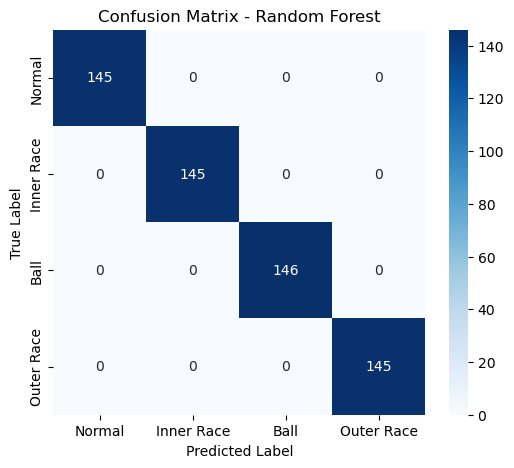

Model saved to ../Trained_models/rf_classifier.pkl

Training Support Vector Machine...
Model trained successfully.
Test Accuracy: 1.0000
F1 Score: 1.0000


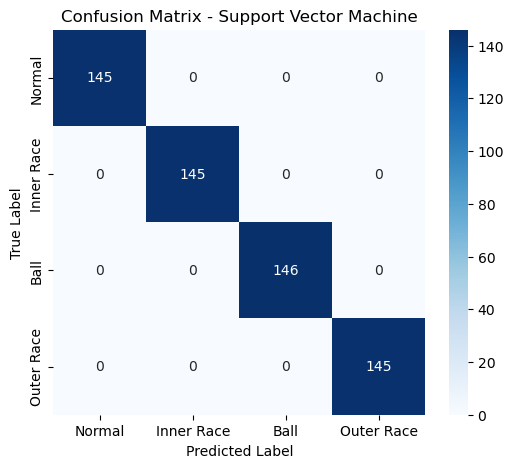

Model saved to ../Trained_models/svm_classifier.pkl

Training Gradient Boosting...
Model trained successfully.
Test Accuracy: 1.0000
F1 Score: 1.0000


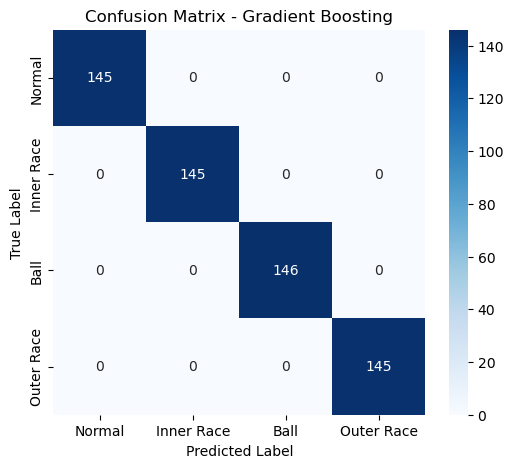

Model saved to ../Trained_models/gb_classifier.pkl


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# Split Data (Using Balanced Data)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

models_to_train = ['rf', 'svm', 'gb']
model_names = {'rf': 'Random Forest', 'svm': 'Support Vector Machine', 'gb': 'Gradient Boosting'}
results = []

for model_type in models_to_train:
    print(f"\n{'='*40}")
    print(f"Training {model_names[model_type]}...")
    print(f"{'='*40}")
    
    # Initialize and Train
    model = FaultDiagnosisModel(model_type=model_type)
    model.train(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Test Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_names[model_type]}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Save Model
    save_path = f'../Trained_models/cwru_ml/{model_type}_classifier.pkl'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save_model(save_path)
    
    # Store Results
    results.append({
        'Model': model_names[model_type],
        'Accuracy': acc,
        'F1 Score': f1
    })

## 6. Comparative Analysis
Now let's compare the performance of the three models side-by-side.

                    Model  Accuracy  F1 Score
0           Random Forest       1.0       1.0
1  Support Vector Machine       1.0       1.0
2       Gradient Boosting       1.0       1.0


C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_7272\1926314132.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')


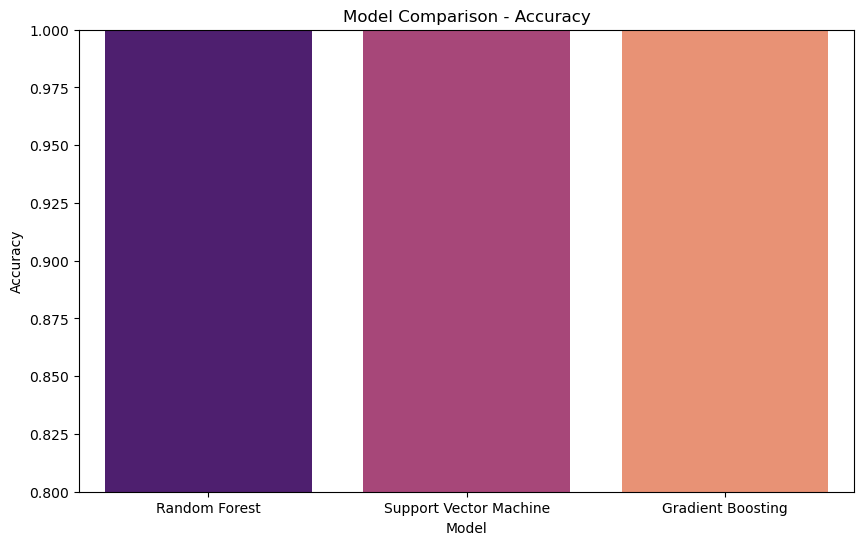

C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_7272\1926314132.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 Score', data=results_df, palette='magma')


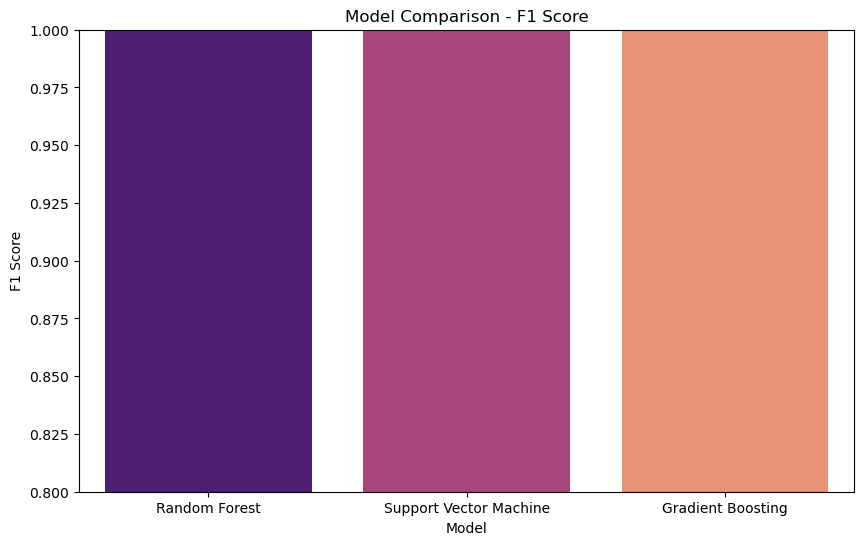

In [8]:
# Create DataFrame from results
results_df = pd.DataFrame(results)
print(results_df)

# Plot Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')
plt.title('Model Comparison - Accuracy')
plt.ylim(0.8, 1.0) # Zoom in to see differences if accuracy is high
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1 Score', data=results_df, palette='magma')
plt.title('Model Comparison - F1 Score')
plt.ylim(0.8, 1.0)
plt.ylabel('F1 Score')
plt.show()

### Conclusion:
Based on the charts above, you can determine which model provides the best balance of accuracy and reliability for your specific dataset. 
*   **Random Forest** is often robust and easy to tune.
*   **SVM** works well for high-dimensional data but can be slower.
*   **Gradient Boosting** often achieves the highest accuracy but requires careful tuning.

In [ ]:
# Class Distribution
plt.figure(figsize=(12, 6))
class_counts = y_train.value_counts().sort_index()
plt.bar(range(len(class_counts)), class_counts.values, edgecolor='black', alpha=0.7)
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Fault Class')
plt.ylabel('Number of Samples')
plt.xticks(range(len(class_counts)), class_counts.index)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print(f'Total Training Samples: {len(y_train)}')
print(f'Number of Classes: {len(class_counts)}')

In [ ]:
# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

# RMS
axes[0, 0].hist(X_train['rms'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('RMS Distribution')
axes[0, 0].set_xlabel('RMS Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Kurtosis
axes[0, 1].hist(X_train['kurtosis'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Kurtosis Distribution')
axes[0, 1].set_xlabel('Kurtosis Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Skewness
axes[1, 0].hist(X_train['skewness'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Skewness Distribution')
axes[1, 0].set_xlabel('Skewness Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Peak-to-Peak
if 'peak_to_peak' in X_train.columns:
    axes[1, 1].hist(X_train['peak_to_peak'], bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Peak-to-Peak Distribution')
    axes[1, 1].set_xlabel('Peak-to-Peak Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Feature Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(12, 10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Individual Confusion Matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

for model_name in results.keys():
    y_pred = results[model_name]['predictions']
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, 
                cbar_kws={"shrink": 0.8})
    plt.title(f'{model_name} - Confusion Matrix\nAccuracy: {results[model_name]["accuracy"]:.4f}', 
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Per-Class Performance for Each Model
from sklearn.metrics import classification_report

for model_name in results.keys():
    y_pred = results[model_name]['predictions']
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extract per-class metrics
    classes = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
    precision = [report[c]['precision'] for c in classes]
    recall = [report[c]['recall'] for c in classes]
    f1 = [report[c]['f1-score'] for c in classes]
    
    # Plot
    x = range(len(classes))
    width = 0.25
    
    plt.figure(figsize=(14, 6))
    plt.bar([i - width for i in x], precision, width, label='Precision', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', alpha=0.8)
    plt.bar([i + width for i in x], f1, width, label='F1-Score', alpha=0.8)
    
    plt.title(f'{model_name} - Per-Class Performance', fontsize=14, fontweight='bold')
    plt.xlabel('Class')
    plt.ylabel('Score')
    plt.xticks(x, classes)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

## Data Exploration Visualizations


In [ ]:
# Class Distribution
plt.figure(figsize=(12, 6))
class_counts = y_train.value_counts().sort_index()
plt.bar(range(len(class_counts)), class_counts.values, edgecolor='black', alpha=0.7)
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Fault Class')
plt.ylabel('Number of Samples')
plt.xticks(range(len(class_counts)), class_counts.index)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print(f'Total Training Samples: {len(y_train)}')
print(f'Number of Classes: {len(class_counts)}')

In [ ]:
# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

# RMS
axes[0, 0].hist(X_train['rms'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('RMS Distribution')
axes[0, 0].set_xlabel('RMS Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Kurtosis
axes[0, 1].hist(X_train['kurtosis'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Kurtosis Distribution')
axes[0, 1].set_xlabel('Kurtosis Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Skewness
axes[1, 0].hist(X_train['skewness'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Skewness Distribution')
axes[1, 0].set_xlabel('Skewness Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Peak-to-Peak
if 'peak_to_peak' in X_train.columns:
    axes[1, 1].hist(X_train['peak_to_peak'], bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Peak-to-Peak Distribution')
    axes[1, 1].set_xlabel('Peak-to-Peak Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Feature Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(12, 10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Performance Visualizations


In [ ]:
# Individual Confusion Matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

for model_name in results.keys():
    y_pred = results[model_name]['predictions']
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, 
                cbar_kws={"shrink": 0.8})
    plt.title(f'{model_name} - Confusion Matrix\nAccuracy: {results[model_name]["accuracy"]:.4f}', 
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Per-Class Performance for Each Model
from sklearn.metrics import classification_report

for model_name in results.keys():
    y_pred = results[model_name]['predictions']
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extract per-class metrics
    classes = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
    precision = [report[c]['precision'] for c in classes]
    recall = [report[c]['recall'] for c in classes]
    f1 = [report[c]['f1-score'] for c in classes]
    
    # Plot
    x = range(len(classes))
    width = 0.25
    
    plt.figure(figsize=(14, 6))
    plt.bar([i - width for i in x], precision, width, label='Precision', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', alpha=0.8)
    plt.bar([i + width for i in x], f1, width, label='F1-Score', alpha=0.8)
    
    plt.title(f'{model_name} - Per-Class Performance', fontsize=14, fontweight='bold')
    plt.xlabel('Class')
    plt.ylabel('Score')
    plt.xticks(x, classes)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()